# GRF model - experiment 3

This notebook attempts to reproduce the `nl_t_norm.R` script but using EconML. The goal is to have a nonlinear effect of `T` on the treatment effect `tau`, which can then be recovered. This adds a nonlinear effect of `X` on `y` (non-confounding)

In [154]:
from econml.grf import CausalForest, RegressionForest
from econml.dml import CausalForestDML
import numpy as np
import pandas as pd
import scipy.special
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree

np.random.seed(42)

## Set up data

Step 1: create 'true' functions (these dont all work at present)

In [155]:
## y as true function of X
def true_y_x(X):
    return (X[:,0] > 0) * X[:,0]
    # return X[:,0]
## tau as true function X
def true_te_x(X):
    # return (X[:,0] > 0)
    return X[:,0] * 0

## y as true function of T
def true_y_t(T):
    return (T > 0) * T  
## tau as true function of T
def true_te_t(T, t_eff):
    return (T > 0) * t_eff 

Step 2: Set up experiment parameters

In [156]:
n_samples = 5000
n_features = 4
n_treatments = 1
n_outputs = 1

In [157]:
## Create features
X = np.random.normal(size=(n_samples, n_features))

In [158]:
## Create treatment
T = np.random.normal(size=(n_samples)) ## No confounder
# T = np.random.normal(size=(n_samples)) + 0.2 * X[:,0] ## Linear confounder
# T = np.random.normal(size=(n_samples)) + 0.2 * (X[:,0] > 0) ## Nonlinear confounder

In [159]:
## Make outcome: nonlinear treatment effect only
t_eff = 2
x_eff = 1
y = t_eff * true_y_t(T) + x_eff * true_y_x(X)

## Noise on Y
y_e = np.random.normal(loc = 0.0, scale = 0.1, size=(n_samples))
y = y + y_e 

Make up test data (for plotting), one with only `X` and one with `X` and `T`

In [160]:
## Test set for plotting
n_test = 100
X_test = np.zeros((n_test, n_features))
X_test[:,0] = np.linspace(-3, 3, 100)

X_T_test_x = np.zeros((n_test, n_features + 1))
X_T_test_x[:,0] = np.linspace(-3, 3, 100)
X_T_test_x[:,4] = X_T_test_x[:,4] - 1 # Set to arbitrary low value

X_T_test_t = np.zeros((n_test, n_features + 1))
X_T_test_t[:,n_features] = np.linspace(-3, 3, 100)

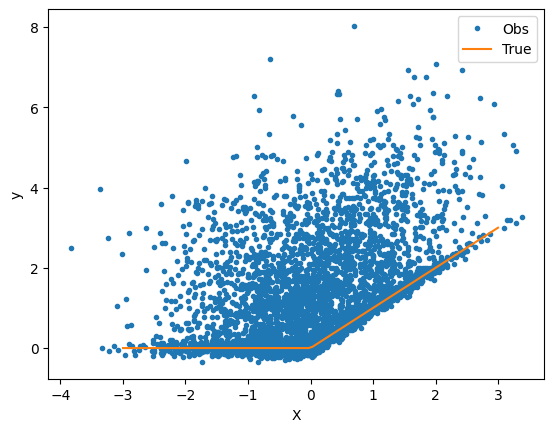

In [161]:
## Plot of y as function of X[:,0]

plt.plot(X[:,0], y, '.', label = "Obs")
plt.plot(X_T_test_x[:,0], true_y_x(X_T_test_x) * x_eff, label = "True")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

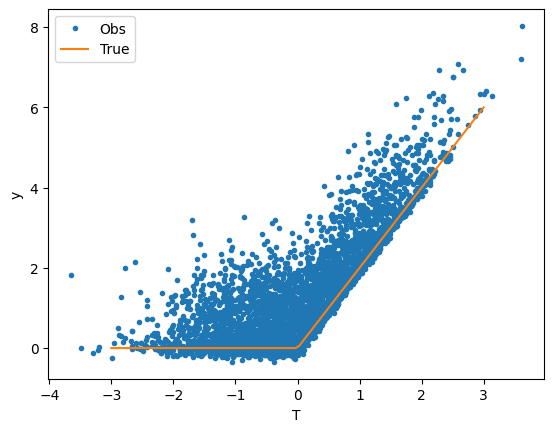

In [162]:
## Plot of y as function of T

plt.plot(T, y, '.', label = "Obs")
plt.plot(X_T_test[:,4], true_y_t(X_T_test[:,4]) * t_eff, label = "True")
plt.xlabel('T')
plt.ylabel('y')
plt.legend()

## Two stage estimator

Uses `RegressionForest` to create propensity and nuisance models and calculate residuals from these (`T'` and `y'`).

In [163]:
## Nusiance model
mod_n = RegressionForest()
mod_n.fit(X, y)

y_hat = mod_n.predict(X)
y_prime = y - y_hat[:,0]

In [164]:
## Propensity model
mod_p = RegressionForest()
mod_p.fit(X, T)

T_hat = mod_p.predict(X)
T_prime = T - T_hat[:,0]

Now add `T` into the `X` array and pass to `CausalForest`

In [165]:
X_T = np.concatenate((X, T[:, np.newaxis]), axis=1)

In [166]:
mod_cf = CausalForest(criterion='het', n_estimators=400, 
                    verbose=0, 
                    n_jobs=-1, random_state=123)
# mod_cf.fit(X, T, y)
%time mod_cf.fit(X_T, T_prime, y_prime)

CPU times: user 3.45 s, sys: 110 ms, total: 3.56 s
Wall time: 449 ms


CausalForest(criterion='het', n_estimators=400, random_state=123)

Plot true and estimated `tau` values across range of `X`

In [167]:
X_T_test_x

array([[-3.        ,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.93939394,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.87878788,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.81818182,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.75757576,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.6969697 ,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.63636364,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.57575758,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.51515152,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.45454545,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.39393939,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.33333333,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.27272727,  0.        ,  0.        ,  0.        , -1.        ],
       [-2.21212121,  0.        ,  0. 

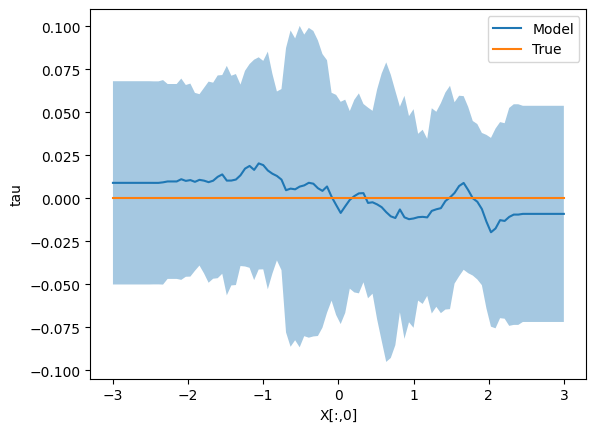

In [168]:
tau_hat = mod_cf.predict(X_T_test_x)
lb, ub = mod_cf.predict_interval(X_T_test_x)

plt.plot(X_T_test_x[:,0], tau_hat, label='Model')
plt.fill_between(X_T_test_x[:,0], lb[:,0], ub[:,0], alpha = 0.4)
plt.plot(X_T_test_x[:,0], true_te_x(X_T_test_x), label='True')
plt.xlabel("X[:,0]")
plt.ylabel("tau")
plt.legend()

Plot true and estimated `tau` values across range of `T`

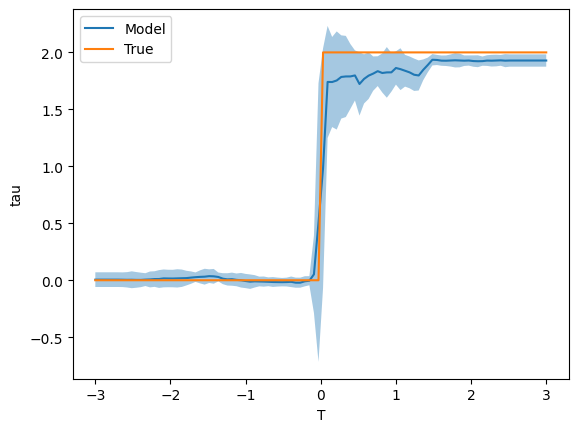

In [169]:
tau_hat = mod_cf.predict(X_T_test_t)
lb, ub = mod_cf.predict_interval(X_T_test_t)

plt.plot(X_T_test_t[:,4], tau_hat, label='Model')
plt.fill_between(X_T_test_t[:,4], lb[:,0], ub[:,0], alpha = 0.4)
plt.plot(X_T_test_t[:,4], true_te_t(X_T_test_t[:,4], t_eff), label='True')
plt.xlabel("T")
plt.ylabel("tau")
plt.legend()

And plot estimated outcome

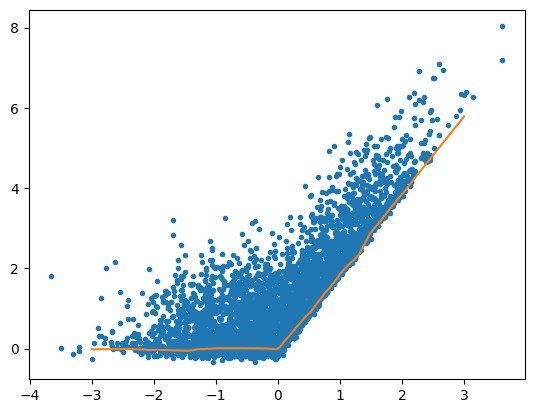

In [170]:
y_pred = tau_hat[:,0] * X_T_test[:,4]

plt.plot(T, y, '.', label = 'Obs')
#plt.plot(X_T_test[:,4], y_pred, label='Model')
# plt.fill_between(X_test[:,0], lb - y_pred, ub + y_pred, alpha = 0.4)
plt.plot(X_T_test[:,4], y_pred, label='True')

In [171]:
var_names = ['X0', 'X1', 'X2', 'X3', 'T']

importances = mod_cf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X.shape[1]):
    print("%d. feature %d %s (%f)" % (f + 1, indices[f], var_names[indices[f]], importances[indices[f]]))

Feature ranking:
1. feature 4 T (0.996431)
2. feature 0 X0 (0.001222)
3. feature 1 X1 (0.000869)
4. feature 3 X3 (0.000830)


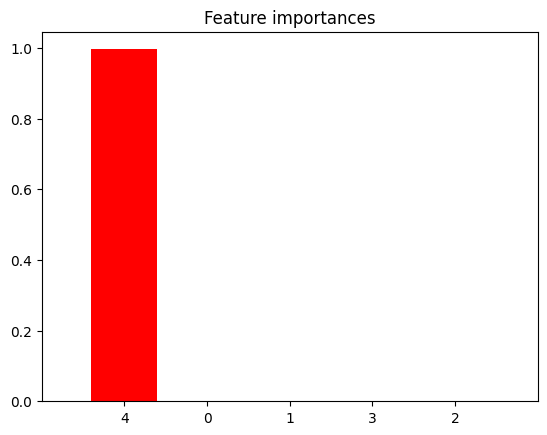

In [172]:
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_T.shape[1]), importances[indices],
        color="r", align="center")
plt.xticks(range(X_T.shape[1]), indices)
plt.xlim([-1, X_T.shape[1]])
plt.show()

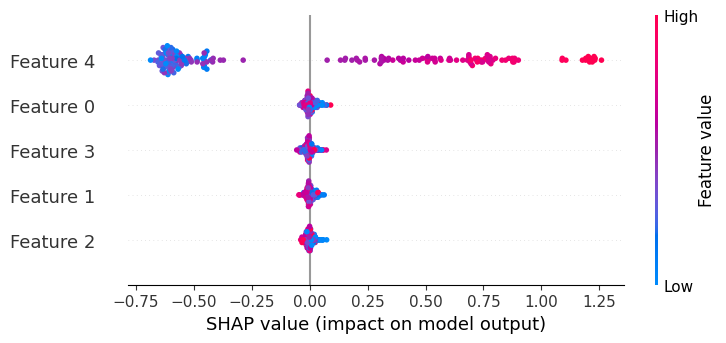

In [173]:
import shap
explainer = shap.Explainer(mod_cf, shap.maskers.Independent(X_T, max_samples=100))
shap_values = explainer(X_T[:200])
shap.plots.beeswarm(shap_values)